# 02 — Modelling: baseline, SARIMA, Prophet, LSTM under one CV

> **This data is synthetic** (generated by `src/generate_data.py`). Not real.

Four forecasters on **identical** rolling-origin folds, scored with **MASE** against the seasonal-naive baseline. The metric and the CV harness live in `src/evaluation.py`; the models share one fit/predict interface in `src/models.py`.

### Part A — harness + baseline
Built first and gated by two correctness checks before anything else is admitted:
- **Gate 1 (sanity)** — seasonal-naive MASE under CV must be ≈ 1.0.
- **Gate 2 (cross-check)** — hand-rolled MASE must match `utilsforecast.losses.mase` to fp tolerance.

### Part B — three more models (SARIMA / SARIMAX, Prophet, LSTM)
All through the **same** harness, **same** 26 folds, **fresh** model per fold.

### Leakage discipline (carried from the EDA stage)
- Target input: **lagged `sales` only**.
- Exogenous input: the event flags `is_match_day`, `is_bank_holiday`, and `match_importance`. All three are **known-future** (see the note in §B.0 below on why `match_importance` qualifies).
- The generator's ground-truth columns (`baseline/trend/weekly/annual/events/mu`) are **never** features.
- **No random splits anywhere.** Time-ordered, expanding-window folds only.


In [1]:
from __future__ import annotations
import sys, warnings, logging, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# Quiet down the heavyweight libs so notebook output stays readable.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
warnings.filterwarnings("ignore")
for nm in ("prophet", "cmdstanpy", "tensorflow"):
    logging.getLogger(nm).setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_SEED, set_seeds
from src.evaluation import (
    CVConfig, rolling_origin_cv, summarize, mase, mae, seasonal_naive_scale,
)
from src.models import SeasonalNaive, SARIMAXModel, ProphetModel, LSTMModel

set_seeds(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
print(f"seed={RANDOM_SEED}  results={RESULTS.relative_to(ROOT)}")


seed=42  results=results


## A.1 · Load the series and the known-future event flags

In [2]:
df = pd.read_csv(ROOT / "data" / "sales.csv", comment="#", parse_dates=["date"])
df = df.set_index("date").asfreq("D")
assert df.index.freq is not None and df["sales"].isna().sum() == 0

y = df["sales"]
# Part A used 2 flags. Part B adds match_importance (justified in §B.0).
X = df[["is_match_day", "match_importance", "is_bank_holiday"]].astype(float)

print(f"y: {len(y):,} daily obs, {y.index.min().date()} -> {y.index.max().date()}")
print(f"X: exogenous regressors = {list(X.columns)}")


y: 1,096 daily obs, 2022-01-01 -> 2024-12-31
X: exogenous regressors = ['is_match_day', 'match_importance', 'is_bank_holiday']


## A.2 · The one shared CV configuration

Every model is scored on **these exact folds** — same cutoffs, same test weeks, same per-fold scale.

- **Horizon h = 7** — one week ahead, matching the ordering/rostering decision.
- **Step = 7**, expanding window, **26 weekly origins** (non-overlapping test blocks).
- First fold trains on ~2.5 years; last fold's test block ends on the final observation.


In [3]:
cv = CVConfig(horizon=7, step_size=7, n_origins=26, m=7)
folds = cv.describe(y.index)
print(f"{len(folds)} expanding-window folds")
print(f"first fold trains on {folds.iloc[0]['n_train']} days "
      f"(-> {folds.iloc[0]['train_end']}), tests {folds.iloc[0]['test_start']}..{folds.iloc[0]['test_end']}")
print(f"last  fold trains on {folds.iloc[-1]['n_train']} days "
      f"(-> {folds.iloc[-1]['train_end']}), tests {folds.iloc[-1]['test_start']}..{folds.iloc[-1]['test_end']}")
pd.concat([folds.head(3), folds.tail(3)])


26 expanding-window folds
first fold trains on 914 days (-> 2024-07-02), tests 2024-07-03..2024-07-09
last  fold trains on 1089 days (-> 2024-12-24), tests 2024-12-25..2024-12-31


,fold,n_train,train_start,train_end,test_start,test_end
0,0,914,2022-01-01,2024-07-02,2024-07-03,2024-07-09
1,1,921,2022-01-01,2024-07-09,2024-07-10,2024-07-16
2,2,928,2022-01-01,2024-07-16,2024-07-17,2024-07-23
23,23,1075,2022-01-01,2024-12-10,2024-12-11,2024-12-17
24,24,1082,2022-01-01,2024-12-17,2024-12-18,2024-12-24
25,25,1089,2022-01-01,2024-12-24,2024-12-25,2024-12-31


## A.3 · MASE — scaled against the in-sample, training-only seasonal naive

The MASE denominator (the *scale*) uses the **training portion only**: $\text{scale} = \frac{1}{n-m}\sum_{t=m+1}^{n}\lvert y^{tr}_t - y^{tr}_{t-m}\rvert$, with $m=7$. The test set never enters it. **MASE < 1 means "beats the seasonal-naive baseline".** MAPE is deliberately not used: a sports bar has very quiet days and MAPE explodes near zero.


## A.4 · Seasonal-naive baseline through the harness

In [4]:
baseline_folds, baseline_preds = rolling_origin_cv(
    SeasonalNaive, y, cv, model_name="SeasonalNaive"
)
baseline_summary = summarize(baseline_folds)
baseline_summary


,model,n_folds,mase_mean,mase_median,mase_std,mae_mean,rmse_mean
0,SeasonalNaive,26,0.94647,0.917951,0.301987,291.667802,369.76065


## A.5 · GATE 1 — seasonal-naive MASE must be ≈ 1.0

In [5]:
m_mean = baseline_summary["mase_mean"].iloc[0]
m_med = baseline_summary["mase_median"].iloc[0]
passed = 0.7 <= m_mean <= 1.4
print(f"Seasonal-naive MASE under CV:  mean = {m_mean:.4f},  median = {m_med:.4f}")
print(f"per-fold range: [{baseline_folds['mase'].min():.3f}, {baseline_folds['mase'].max():.3f}]")
print(f"\nGATE 1: {'PASS — scaling is correct (~1.0)' if passed else 'FAIL — MASE scaling is wrong'}")
assert passed


Seasonal-naive MASE under CV:  mean = 0.9465,  median = 0.9180
per-fold range: [0.392, 1.617]

GATE 1: PASS — scaling is correct (~1.0)


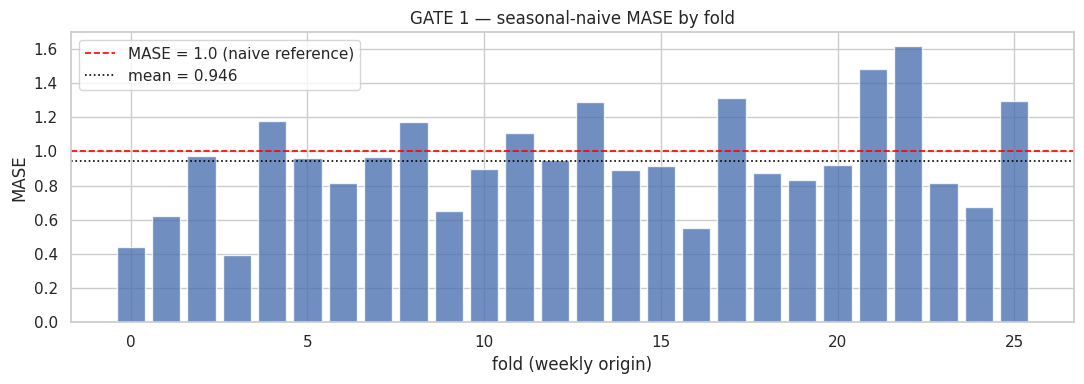

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(baseline_folds["fold"], baseline_folds["mase"], color="C0", alpha=0.8)
ax.axhline(1.0, color="red", ls="--", lw=1.2, label="MASE = 1.0 (naive reference)")
ax.axhline(m_mean, color="black", ls=":", lw=1.2, label=f"mean = {m_mean:.3f}")
ax.set_title("GATE 1 — seasonal-naive MASE by fold")
ax.set_xlabel("fold (weekly origin)"); ax.set_ylabel("MASE")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "model_00_baseline_sanity.png")
plt.show()


## A.6 · GATE 2 — cross-check against `utilsforecast.losses.mase`

In [7]:
from utilsforecast.losses import mase as uf_mase

def uf_mase_one_fold(fold_idx: int) -> float:
    cutoff, ts, te = cv.splits(len(y))[fold_idx]
    y_tr, y_te = y.iloc[:cutoff], y.iloc[ts:te]
    y_hat = SeasonalNaive(m=cv.m).fit(y_tr).predict(cv.horizon)
    train_df = pd.DataFrame({"unique_id": "bar", "ds": y_tr.index, "y": y_tr.values})
    eval_df = pd.DataFrame({"unique_id": "bar", "ds": y_te.index,
                            "y": y_te.values, "SeasonalNaive": y_hat})
    return float(uf_mase(eval_df, models=["SeasonalNaive"],
                         seasonality=cv.m, train_df=train_df)["SeasonalNaive"].iloc[0])

max_diff = max(
    abs(baseline_folds.loc[baseline_folds['fold'] == k, 'mase'].iloc[0] - uf_mase_one_fold(k))
    for k in baseline_folds["fold"]
)
print(f"Across all {len(baseline_folds)} folds: max |hand - utilsforecast| = {max_diff:.2e}")
print(f"GATE 2: {'PASS — matches utilsforecast to fp tolerance' if max_diff < 1e-9 else 'FAIL'}")
assert max_diff < 1e-9


Across all 26 folds: max |hand - utilsforecast| = 3.33e-16
GATE 2: PASS — matches utilsforecast to fp tolerance


In [8]:
baseline_folds.to_csv(RESULTS / "cv_baseline_per_fold.csv", index=False)
baseline_summary.to_csv(RESULTS / "cv_baseline_summary.csv", index=False)


---

# Part B — SARIMA, Prophet, LSTM

Three more models, **same** harness, **same** 26 folds, **fresh** model per fold.

## B.0 · `match_importance` as a known-future regressor

`match_importance` is set by the generator at fixture-creation time from a single `Beta(2, 5)` draw (see `src/generate_data.py` line 233). It depends on no realised outcome, no attendance, no sales — it encodes the inherent draw of a fixture (rivalry, league/cup stakes, billing). A bar manager planning rotas the week before knows all of these. **Pre-match → legitimate known-future regressor.** SARIMAX and Prophet take it as exog alongside the two binary flags.


## B.1 · SARIMAX — three candidate orders

Starting point per the EDA's ACF/PACF: the **airline model** $(0,1,1)(0,1,1,7)$ — first difference + seasonal MA(1) + non-seasonal MA(1). Two neighbours for honest model selection:

1. **Airline** — `order=(0,1,1)`, `seasonal_order=(0,1,1,7)`, no trend.
2. **+AR(1)** — `order=(1,1,1)`, `seasonal_order=(0,1,1,7)`, no trend. Checks whether adding short-run autoregression helps.
3. **d=0 + drift** — `order=(0,0,1)`, `seasonal_order=(0,1,1,7)`, `trend='ct'`. Replaces the first difference with an explicit constant + linear drift.

Selection by **AIC on the first fold's training set + walk-forward MASE across all 26 folds**. The walk-forward MASE is the decision criterion; AIC is reported as the parametric model-selection sanity check.

All three carry the same exog block: `is_match_day`, `match_importance`, `is_bank_holiday`.


In [9]:
SARIMAX_CANDIDATES = {
    "SARIMAX_airline_(0,1,1)(0,1,1,7)": dict(order=(0,1,1), seasonal_order=(0,1,1,7), trend=None),
    "SARIMAX_+AR1_(1,1,1)(0,1,1,7)":    dict(order=(1,1,1), seasonal_order=(0,1,1,7), trend=None),
    "SARIMAX_drift_(0,0,1)(0,1,1,7)":   dict(order=(0,0,1), seasonal_order=(0,1,1,7), trend="ct"),
}

# AIC on the first fold's training set (the smallest training set; gives every
# candidate the same comparison footing).
first_cutoff = cv.splits(len(y))[0][0]
y_tr0 = y.iloc[:first_cutoff]
X_tr0 = X.iloc[:first_cutoff]

aic_rows = []
for label, kw in SARIMAX_CANDIDATES.items():
    m = SARIMAXModel(label=label, **kw).fit(y_tr0, X_tr0)
    aic_rows.append({"order": label, "AIC (first-fold train)": round(m.aic, 1)})
aic_df = pd.DataFrame(aic_rows).set_index("order")
aic_df


,AIC (first-fold train)
order,
"SARIMAX_airline_(0,1,1)(0,1,1,7)",12623.9
"SARIMAX_+AR1_(1,1,1)(0,1,1,7)",12625.7
"SARIMAX_drift_(0,0,1)(0,1,1,7)",12727.7


In [10]:
# Walk-forward MASE for each candidate, through the SAME CV harness.
sarimax_folds_all = []
for label, kw in SARIMAX_CANDIDATES.items():
    factory = (lambda lab=label, k=kw: SARIMAXModel(label=lab, **k))
    print(f"  running {label} ...")
    per_fold, _ = rolling_origin_cv(factory, y, cv, X=X, model_name=label)
    sarimax_folds_all.append(per_fold)
sarimax_per_fold = pd.concat(sarimax_folds_all, ignore_index=True)
sarimax_summary = summarize(sarimax_per_fold).merge(
    aic_df.reset_index().rename(columns={"order": "model"}), on="model", how="left"
)
sarimax_summary


  running SARIMAX_airline_(0,1,1)(0,1,1,7) ...


  running SARIMAX_+AR1_(1,1,1)(0,1,1,7) ...


  running SARIMAX_drift_(0,0,1)(0,1,1,7) ...


,model,n_folds,mase_mean,mase_median,mase_std,mae_mean,rmse_mean,AIC (first-fold train)
0,"SARIMAX_+AR1_(1,1,1)(0,1,1,7)",26,0.660163,0.584513,0.277234,203.509277,248.437804,12625.7
1,"SARIMAX_airline_(0,1,1)(0,1,1,7)",26,0.661607,0.584830,0.278045,203.954821,248.901417,12623.9
2,"SARIMAX_drift_(0,0,1)(0,1,1,7)",26,0.739998,0.670712,0.369126,228.152869,277.230369,12727.7


**Pick by walk-forward MASE** (the test-error criterion), report AIC alongside.


In [11]:
winner_label = sarimax_summary.iloc[0]["model"]
print(f"WINNER: {winner_label}")
print(f"  walk-forward MASE = {sarimax_summary.iloc[0]['mase_mean']:.4f}  "
      f"(median {sarimax_summary.iloc[0]['mase_median']:.4f})")
print(f"  AIC (first-fold) = {sarimax_summary.iloc[0]['AIC (first-fold train)']:.1f}")


WINNER: SARIMAX_+AR1_(1,1,1)(0,1,1,7)
  walk-forward MASE = 0.6602  (median 0.5845)
  AIC (first-fold) = 12625.7


## B.2 · Prophet — flags + match_importance as regressors

Positioned for interpretability, not presumed accuracy. Yearly + weekly seasonality, additive mode, all three exog passed as `add_regressor`. We do **not** call `add_country_holidays` — `is_bank_holiday` is already a regressor and we would otherwise double-count the holiday effect.


In [12]:
prophet_factory = lambda: ProphetModel(regressor_cols=list(X.columns))
print("  running Prophet through CV ...")
prophet_folds, prophet_preds = rolling_origin_cv(
    prophet_factory, y, cv, X=X, model_name="Prophet"
)
summarize(prophet_folds)


Importing plotly failed. Interactive plots will not work.


17:38:28 - cmdstanpy - INFO - Chain [1] start processing


  running Prophet through CV ...


17:38:29 - cmdstanpy - INFO - Chain [1] done processing


,model,n_folds,mase_mean,mase_median,mase_std,mae_mean,rmse_mean
0,Prophet,26,0.642731,0.575898,0.284551,198.116126,238.12579


## B.3 · LSTM — modest, single-layer, honest

Deliberately conservative architecture (no win-chasing): one LSTM layer with 32 units, 28-day lookback, direct 7-step Dense output, dropout 0.1, Adam @ 1e-3, early stopping (patience 8) on a tail-15% validation split (`shuffle=False`). Target standard-scaled on **training data only**, per fold.

The brief — and the M4 / M5 literature it points at — says a high-capacity neural network is **expected to underperform** the classical methods on a single short series. The mechanism (Montero-Manso & Hyndman 2021): neural methods need to pool *many* series to avoid overfitting; their power comes from cross-learning, which one venue cannot provide. M4 showed no pure-ML entry beat the simple combination benchmark and only one beat the naive benchmark; M5 reversed that, but only with thousands of series and global models. We include the LSTM, watch where it lands, and explain — we are not tuning it toward a win.


In [13]:
lstm_factory = lambda: LSTMModel(
    horizon=cv.horizon, lookback=28, units=32, dropout=0.1,
    max_epochs=60, patience=8, batch_size=32, val_frac=0.15,
    learning_rate=1e-3, seed=RANDOM_SEED,
)
print("  running LSTM through CV (this is the slow one — 26 fresh fits) ...")
lstm_folds, lstm_preds = rolling_origin_cv(
    lstm_factory, y, cv, X=X, model_name="LSTM"
)
summarize(lstm_folds)


  running LSTM through CV (this is the slow one — 26 fresh fits) ...


,model,n_folds,mase_mean,mase_median,mase_std,mae_mean,rmse_mean
0,LSTM,26,0.777393,0.728612,0.278021,239.61127,299.620483


## B.4 · All-model comparison


In [14]:
all_per_fold = pd.concat(
    [baseline_folds,
     sarimax_per_fold[sarimax_per_fold["model"] == winner_label],
     prophet_folds, lstm_folds],
    ignore_index=True,
)
all_summary = summarize(all_per_fold)
all_summary.to_csv(RESULTS / "cv_all_models_summary.csv", index=False)
all_per_fold.to_csv(RESULTS / "cv_all_models_per_fold.csv", index=False)
# Also persist the SARIMAX candidate comparison for the audit trail
sarimax_summary.to_csv(RESULTS / "cv_sarimax_candidates_summary.csv", index=False)
all_summary


,model,n_folds,mase_mean,mase_median,mase_std,mae_mean,rmse_mean
0,Prophet,26,0.642731,0.575898,0.284551,198.116126,238.125790
1,"SARIMAX_+AR1_(1,1,1)(0,1,1,7)",26,0.660163,0.584513,0.277234,203.509277,248.437804
2,LSTM,26,0.777393,0.728612,0.278021,239.611270,299.620483
3,SeasonalNaive,26,0.946470,0.917951,0.301987,291.667802,369.760650


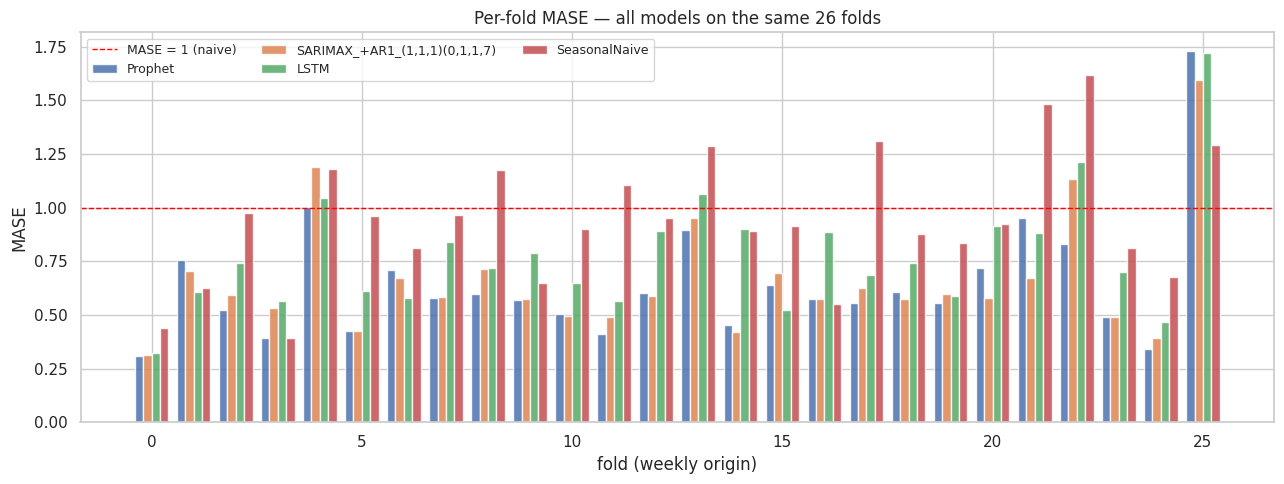

In [15]:
# Per-fold MASE bar chart — by model and fold
order_for_plot = list(all_summary["model"])
fig, ax = plt.subplots(figsize=(13, 5))
fold_ids = sorted(all_per_fold["fold"].unique())
width = 0.2
colors = sns.color_palette("deep", len(order_for_plot))
for j, m in enumerate(order_for_plot):
    sub = all_per_fold[all_per_fold["model"] == m].sort_values("fold")
    ax.bar(np.array(fold_ids) + (j - 1.5) * width, sub["mase"].values,
           width=width, label=m, color=colors[j], alpha=0.85)
ax.axhline(1.0, color="red", ls="--", lw=1, label="MASE = 1 (naive)")
ax.set_xlabel("fold (weekly origin)")
ax.set_ylabel("MASE")
ax.set_title("Per-fold MASE — all models on the same 26 folds")
ax.legend(loc="upper left", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "model_01_per_fold_mase.png")
plt.show()


## B.5 · Forecast-vs-actual — the headline plot

All 26 weekly test segments stitched into one timeline, each model's prediction overlaid against the actual. This is the chart the recruiter audience should be able to glance at and see the picture: how each model tracks the rhythm and where they diverge.


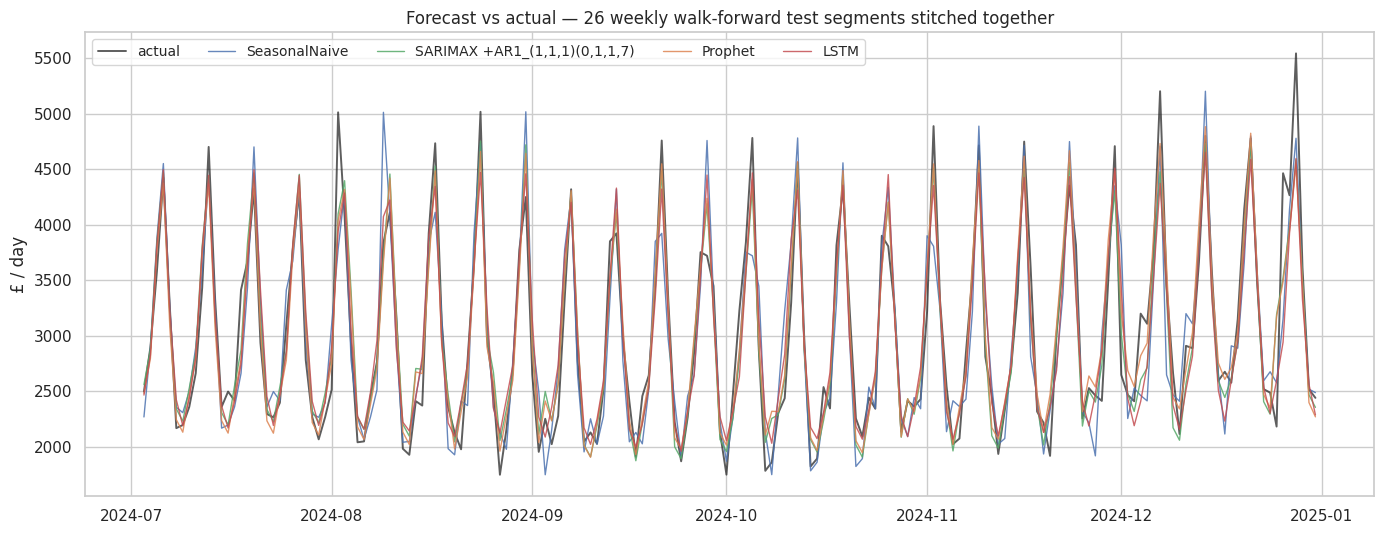

In [16]:
# Stitch all test-segment predictions into one long timeline per model
def _stitched(per_fold_preds):
    return per_fold_preds.sort_values("date").reset_index(drop=True)

baseline_long = _stitched(baseline_preds)
prophet_long  = _stitched(prophet_preds)
lstm_long     = _stitched(lstm_preds)

# SARIMAX winner: need to recompute predictions for the winning candidate
winner_kw = SARIMAX_CANDIDATES[winner_label]
winner_factory = (lambda: SARIMAXModel(label=winner_label, **winner_kw))
_, sarimax_winner_preds = rolling_origin_cv(
    winner_factory, y, cv, X=X, model_name=winner_label
)
sarimax_long = _stitched(sarimax_winner_preds)

stitched_actuals = baseline_long[["date", "actual"]]

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(stitched_actuals["date"], stitched_actuals["actual"], "k-",
        lw=1.4, alpha=0.7, label="actual")
ax.plot(baseline_long["date"], baseline_long["prediction"], lw=1.0,
        color="C0", alpha=0.85, label="SeasonalNaive")
ax.plot(sarimax_long["date"], sarimax_long["prediction"], lw=1.0,
        color="C2", alpha=0.85, label=winner_label.replace("SARIMAX_", "SARIMAX "))
ax.plot(prophet_long["date"], prophet_long["prediction"], lw=1.0,
        color="C1", alpha=0.85, label="Prophet")
ax.plot(lstm_long["date"], lstm_long["prediction"], lw=1.0,
        color="C3", alpha=0.85, label="LSTM")
ax.set_title("Forecast vs actual — 26 weekly walk-forward test segments stitched together")
ax.set_ylabel("£ / day")
ax.legend(ncol=5, loc="upper left", fontsize=10)
fig.tight_layout()
fig.savefig(RESULTS / "model_02_forecast_vs_actual.png")
plt.show()


## B.6 · Summary

All four models were scored on the **same 26 folds** under the **same** rolling-origin harness with MASE scaled against each fold's **training-only** seasonal-naive error. The full comparison and per-fold scores are persisted to `results/`. Order selection and the recruiter-facing chart write-up belong to Stage 5 / 7 — this notebook delivers the honest numbers and stops short of marketing them.
